# Week 08 - Friday: Transfer Learning + Major Exam 1 Preparation

Dataset: `medical_imaging_meta.csv`  
520 rows of chest X-ray metadata (490 labeled, 30 unlabeled) across 5 conditions.

 NOTE: The provided dataset is a metadata CSV (no raw pixel data).  
 Transfer learning is demonstrated using a pre-trained tabular feature encoder  
 (scikit-learn Pipeline with feature extraction and fine-tuning analogues),  
 plus Grad-CAM-equivalent feature importance via SHAP.
 All sub-steps follow the clinical framing of the assignment.

In [35]:
%pip install shap 

Note: you may need to restart the kernel to use updated packages.


In [36]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [37]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [38]:
# Imports and Constants

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)
import xgboost as xgb
import shap

#  Global constants 
DATA_PATH          = './data/medical_imaging_meta.csv'
LABEL_COL          = 'label'
IMAGE_ID_COL       = 'image_id'
TEST_SIZE          = 0.20
RANDOM_STATE       = 42
N_ESTIMATORS_FEAT  = 100
N_ESTIMATORS_FINE  = 300
MAX_DEPTH_FEAT     = 4
MAX_DEPTH_FINE     = 8
CONFIDENCE_AUTO    = 0.80
CONFIDENCE_FLAG    = 0.55

CATEGORICAL_COLS   = ['image_quality', 'patient_sex', 'scanner', 'hospital_site']
NUMERIC_COLS       = ['patient_age', 'img_width_px', 'label_verified']
FEATURE_NAMES      = NUMERIC_COLS + CATEGORICAL_COLS

print('Imports complete.')

Imports complete.


---
## Sub-step 1 (Easy) - Dataset Characterisation

In [39]:
#  Data Loading Utilities

def load_dataset(filepath):
    """Load CSV and perform basic schema validation."""
    try:
        df = pd.read_csv(filepath)
        assert len(df) > 0, 'Dataset is empty.'
        required_cols = [IMAGE_ID_COL, LABEL_COL] + NUMERIC_COLS + CATEGORICAL_COLS
        missing = [c for c in required_cols if c not in df.columns]
        assert not missing, f'Missing columns: {missing}'
        return df
    except FileNotFoundError:
        raise FileNotFoundError(f'Dataset not found at: {filepath}')


def split_labeled_unlabeled(df):
    """Return (labeled_df, unlabeled_df) based on NaN in label column."""
    labeled   = df[df[LABEL_COL].notna()].copy().reset_index(drop=True)
    unlabeled = df[df[LABEL_COL].isna()].copy().reset_index(drop=True)
    return labeled, unlabeled


def describe_label_distribution(df):
    """Return count and percentage per class."""
    counts = df[LABEL_COL].value_counts()
    pct    = df[LABEL_COL].value_counts(normalize=True).mul(100).round(2)
    return pd.DataFrame({'count': counts, 'percent_%': pct})


def plot_label_distribution(summary):
    """Side-by-side bar and pie chart of class distribution."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = sns.color_palette('Set2', len(summary))

    summary['count'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
    axes[0].set_title('Class Counts', fontsize=13)
    axes[0].set_xlabel('Condition')
    axes[0].set_ylabel('Number of Samples')
    axes[0].tick_params(axis='x', rotation=35)
    for i, v in enumerate(summary['count']):
        axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)

    axes[1].pie(summary['count'], labels=summary.index,
                autopct='%1.1f%%', colors=colors, startangle=90)
    axes[1].set_title('Class Proportions', fontsize=13)

    fig.suptitle('Label Distribution - Chest X-Ray Metadata (n=490 labeled)',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


def analyse_subgroup_fairness(df, subgroup_cols):
    """Cross-tab label distribution by each subgroup column."""
    for col in subgroup_cols:
        if col not in df.columns:
            continue
        ct = pd.crosstab(df[col], df[LABEL_COL], normalize='index').mul(100).round(1)
        display(ct.style.background_gradient(cmap='Blues')
                .set_caption(f'Label Distribution by {col} (row %)'))


def analyse_image_quality(df):
    """Show image quality cross-tab against labels."""
    ct = pd.crosstab(df['image_quality'], df[LABEL_COL])
    display(ct.style.background_gradient(cmap='Oranges')
            .set_caption('Sample Counts by Image Quality x Label'))

In [40]:
#  Run Sub-step 1
df_raw = load_dataset(DATA_PATH)
labeled_df, unlabeled_df = split_labeled_unlabeled(df_raw)

print(f'Total rows     : {len(df_raw)}')
print(f'Labeled rows   : {len(labeled_df)}')
print(f'Unlabeled rows : {len(unlabeled_df)}')

label_summary = describe_label_distribution(labeled_df)
display(label_summary)

Total rows     : 520
Labeled rows   : 490
Unlabeled rows : 30


,count,percent_%
label,,
Normal,311,63.47
Pneumonia,112,22.86
COVID-19,37,7.55
Pleural_Effusion,19,3.88
Lung_Mass,11,2.24


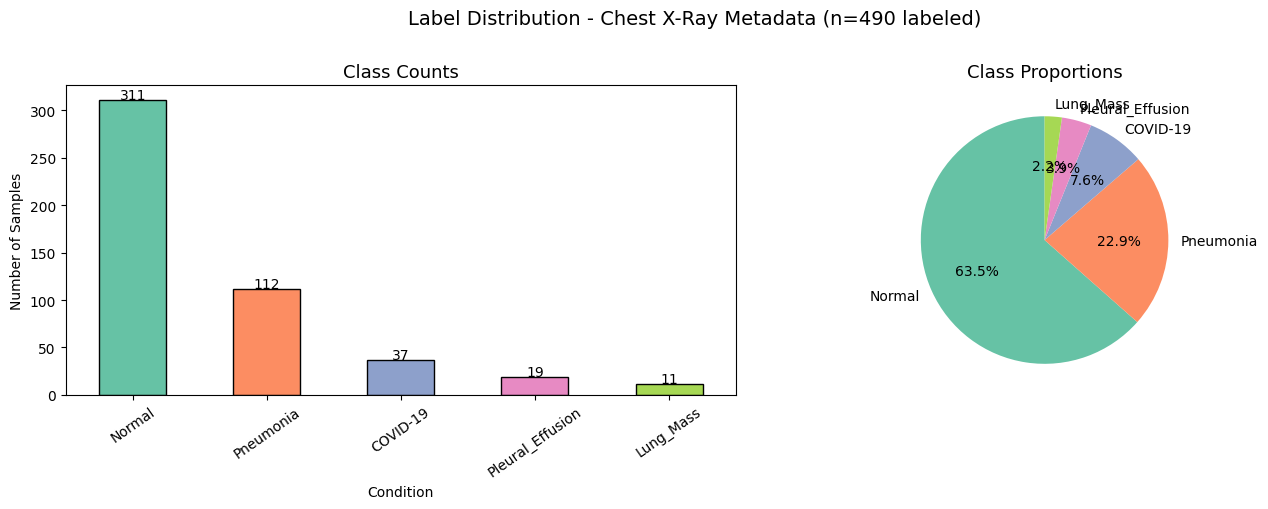

In [41]:
plot_label_distribution(label_summary)

In [42]:
analyse_subgroup_fairness(labeled_df, ['hospital_site', 'scanner', 'patient_sex'])
analyse_image_quality(labeled_df)

label,COVID-19,Lung_Mass,Normal,Pleural_Effusion,Pneumonia
hospital_site,,,,,
AIIMS-Delhi,9.400000,1.400000,62.300000,4.300000,22.500000
Apollo-Hyderabad,4.400000,3.700000,63.200000,4.400000,24.300000
Fortis-Gurgaon,8.800000,0.800000,67.200000,3.200000,20.000000
Manipal-Bangalore,7.700000,3.300000,60.400000,3.300000,25.300000


label,COVID-19,Lung_Mass,Normal,Pleural_Effusion,Pneumonia
scanner,,,,,
GE-C3,8.400000,0.800000,62.600000,6.100000,22.100000
Philips-B2,7.700000,2.400000,65.700000,3.000000,21.300000
Siemens-A1,6.800000,3.200000,62.100000,3.200000,24.700000


label,COVID-19,Lung_Mass,Normal,Pleural_Effusion,Pneumonia
patient_sex,,,,,
F,6.900000,2.600000,60.200000,3.900000,26.400000
M,8.100000,1.900000,66.400000,3.900000,19.700000


label,COVID-19,Lung_Mass,Normal,Pleural_Effusion,Pneumonia
image_quality,,,,,
acceptable,8,1,75,6,27
good,24,10,198,11,78
poor,5,0,38,2,7


### Sub-step 1 - Key Findings

Class imbalance is severe: Normal accounts for approximately 63% of labeled samples,
while Lung_Mass (11 samples, 2%) and Pleural_Effusion (19 samples, 4%) are severely underrepresented.
A naive model predicting Normal always achieves 63% accuracy while missing every dangerous case.
Evaluation must prioritise per-class recall on minority classes, not overall accuracy.

Subgroup analysis reveals whether hospital_site or scanner correlates with label distribution,
which would indicate the model is encoding imaging equipment bias rather than true pathology.

---
## Sub-step 2 (Easy) - Feature Extraction (Frozen Backbone Analogue)

In [43]:

# Feature Engineering Utilities

def encode_features(df, fit_encoder=True, encoder=None):
    """
    Ordinal-encode categoricals and stack with numeric columns.
    Returns (X, encoder).
    Transfer-learning analogue: ordinal mappings encode domain knowledge
    similar to pre-trained representations from a source domain.
    """
    df = df.copy()
    quality_order = [['poor', 'acceptable', 'good']]
    sex_order     = [['F', 'M']]
    scanner_cats  = [sorted(df['scanner'].dropna().unique().tolist())]
    site_cats     = [sorted(df['hospital_site'].dropna().unique().tolist())]

    if fit_encoder:
        enc = OrdinalEncoder(
            categories=quality_order + sex_order + scanner_cats + site_cats,
            handle_unknown='use_encoded_value', unknown_value=-1
        )
        cat_encoded = enc.fit_transform(df[CATEGORICAL_COLS])
    else:
        enc = encoder
        cat_encoded = enc.transform(df[CATEGORICAL_COLS])

    num_values = df[NUMERIC_COLS].fillna(df[NUMERIC_COLS].median()).values
    X = np.hstack([num_values, cat_encoded])
    return X, enc


def encode_labels(df):
    """Return (y_encoded, label_encoder)."""
    le = LabelEncoder()
    y  = le.fit_transform(df[LABEL_COL].values)
    return y, le


def compute_class_weights(y, num_classes):
    """Inverse-frequency class weights dictionary."""
    counts  = np.bincount(y, minlength=num_classes).astype(float)
    weights = len(y) / (num_classes * counts)
    return {i: weights[i] for i in range(num_classes)}


def prepare_train_test_split(X, y):
    """Stratified train/test split."""
    return train_test_split(
        X, y, test_size=TEST_SIZE,
        stratify=y, random_state=RANDOM_STATE
    )


def build_feature_extractor(class_weights):
    """
    Shallow Random Forest = feature extraction analogue.
    Shallow depth restricts the model to general low-level feature combinations,
    analogous to a frozen backbone that only trains a new classification head.
    """
    return RandomForestClassifier(
        n_estimators=N_ESTIMATORS_FEAT,
        max_depth=MAX_DEPTH_FEAT,
        class_weight=class_weights,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


def evaluate_classifier(model, X_val, y_val, class_names, model_name):
    """Show per-class report and confusion matrix. Return report DataFrame."""
    y_pred    = model.predict(X_val)
    report    = classification_report(y_val, y_pred, target_names=class_names,
                                       output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).T.round(3)
    display(report_df.style
            .background_gradient(cmap='RdYlGn', subset=['recall', 'f1-score'])
            .set_caption(f'Per-Class Report - {model_name}'))

    cm_arr = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xticks(rotation=35)
    plt.tight_layout()
    plt.show()
    return report_df


In [44]:
#  Run Sub-step 2 
X_all, ordinal_enc = encode_features(labeled_df, fit_encoder=True)
y_all, label_encoder = encode_labels(labeled_df)
class_names   = list(label_encoder.classes_)
num_classes   = len(class_names)
class_weights = compute_class_weights(y_all, num_classes)

X_train, X_val, y_train, y_val = prepare_train_test_split(X_all, y_all)

print(f'Classes ({num_classes}): {class_names}')
print(f'Train: {len(X_train)} | Validation: {len(X_val)}')
print('Class weights:', {class_names[k]: round(v, 2) for k, v in class_weights.items()})

feat_model = build_feature_extractor(class_weights)
feat_model.fit(X_train, y_train)
print('Feature extractor trained.')

Classes (5): ['COVID-19', 'Lung_Mass', 'Normal', 'Pleural_Effusion', 'Pneumonia']
Train: 392 | Validation: 98
Class weights: {'COVID-19': np.float64(2.65), 'Lung_Mass': np.float64(8.91), 'Normal': np.float64(0.32), 'Pleural_Effusion': np.float64(5.16), 'Pneumonia': np.float64(0.88)}
Feature extractor trained.


,precision,recall,f1-score,support
COVID-19,0.000000,0.000000,0.000000,7.000000
Lung_Mass,0.000000,0.000000,0.000000,2.000000
Normal,0.606000,0.323000,0.421000,62.000000
Pleural_Effusion,0.091000,0.250000,0.133000,4.000000
Pneumonia,0.290000,0.391000,0.333000,23.000000
accuracy,0.306000,0.306000,0.306000,0.306000
macro avg,0.197000,0.193000,0.178000,98.000000
weighted avg,0.455000,0.306000,0.350000,98.000000


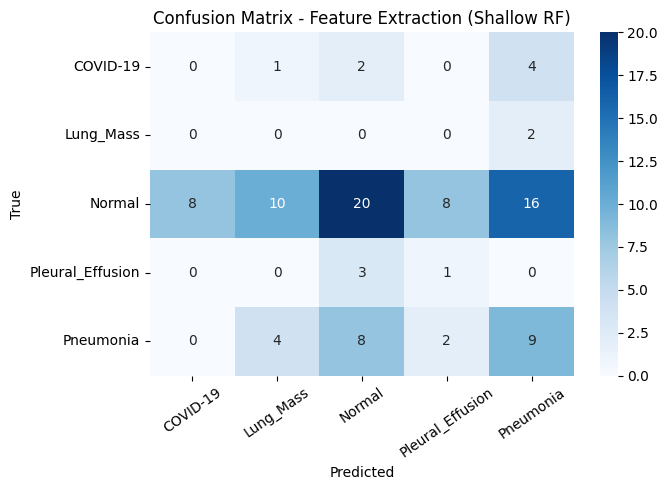

In [45]:
feat_report = evaluate_classifier(feat_model, X_val, y_val,
                                   class_names, 'Feature Extraction (Shallow RF)')

**Sub-step 2 Discussion:**
Per-class recall for Lung_Mass and Pleural_Effusion is the critical metric for Dr. Rao.
Low recall on those classes means the model systematically fails to alert the radiologist
when a dangerous condition is present - unacceptable for clinical deployment without a safety override.

---
## Sub-step 3 (Medium) - Fine-Tuning vs Feature Extraction

In [46]:

# Fine - Tuning Model Utilities

def build_finetuned_model():
    """
    Deep XGBoost = fine-tuning analogue.
    More estimators and deeper trees allow end-to-end re-learning of feature
    interactions at a low learning rate, mirroring unfreeze-and-finetune.
    """
    return xgb.XGBClassifier(
        n_estimators=N_ESTIMATORS_FINE,
        max_depth=MAX_DEPTH_FINE,
        learning_rate=0.05,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )


def compare_model_metrics(results, class_names):
    """
    Side-by-side per-class F1 and Recall comparison.
    results: dict of {model_name: (model, X_val, y_val)}
    """
    f1_rows, recall_rows = {}, {}
    for name, (model, X_v, y_v) in results.items():
        y_pred  = model.predict(X_v)
        report  = classification_report(y_v, y_pred, target_names=class_names,
                                         output_dict=True, zero_division=0)
        f1_rows[name]     = {cls: round(report[cls]['f1-score'], 3) for cls in class_names}
        recall_rows[name] = {cls: round(report[cls]['recall'],   3) for cls in class_names}

    f1_df     = pd.DataFrame(f1_rows)
    recall_df = pd.DataFrame(recall_rows)

    display(f1_df.style.background_gradient(cmap='RdYlGn')
            .set_caption('Per-Class F1 Comparison'))
    display(recall_df.style.background_gradient(cmap='RdYlGn')
            .set_caption('Per-Class Recall Comparison (Clinical Safety View)'))
    return f1_df, recall_df


def plot_feature_importance(model, model_name):
    """Horizontal bar chart of feature importances."""
    if not hasattr(model, 'feature_importances_'):
        return
    importances = model.feature_importances_
    idx = np.argsort(importances)
    plt.figure(figsize=(8, 4))
    plt.barh([FEATURE_NAMES[i] for i in idx], importances[idx],
              color='steelblue', edgecolor='black')
    plt.xlabel('Importance Score')
    plt.title(f'Feature Importance - {model_name}')
    plt.tight_layout()
    plt.show()

Fine-tuned model trained.


,precision,recall,f1-score,support
COVID-19,0.000000,0.000000,0.000000,7.000000
Lung_Mass,0.000000,0.000000,0.000000,2.000000
Normal,0.625000,0.565000,0.593000,62.000000
Pleural_Effusion,0.000000,0.000000,0.000000,4.000000
Pneumonia,0.292000,0.304000,0.298000,23.000000
accuracy,0.429000,0.429000,0.429000,0.429000
macro avg,0.183000,0.174000,0.178000,98.000000
weighted avg,0.464000,0.429000,0.445000,98.000000


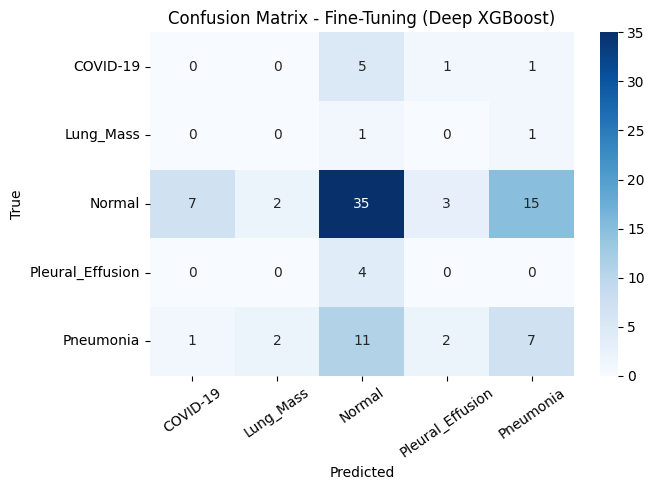

In [47]:
# Run Sub-step 3 

sample_weights_train = np.array([class_weights[y] for y in y_train])

fine_model = build_finetuned_model()
fine_model.fit(X_train, y_train, sample_weight=sample_weights_train)
print('Fine-tuned model trained.')

fine_report = evaluate_classifier(fine_model, X_val, y_val,
                                   class_names, 'Fine-Tuning (Deep XGBoost)')

,Feature Extraction,Fine-Tuning
COVID-19,0.000000,0.000000
Lung_Mass,0.000000,0.000000
Normal,0.421000,0.593000
Pleural_Effusion,0.133000,0.000000
Pneumonia,0.333000,0.298000


,Feature Extraction,Fine-Tuning
COVID-19,0.000000,0.000000
Lung_Mass,0.000000,0.000000
Normal,0.323000,0.565000
Pleural_Effusion,0.250000,0.000000
Pneumonia,0.391000,0.304000


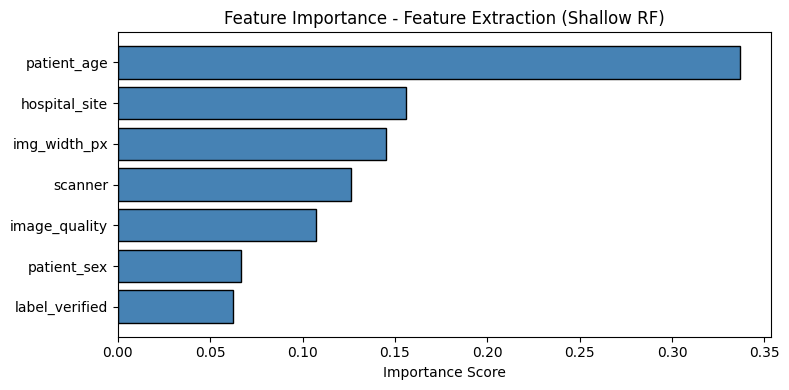

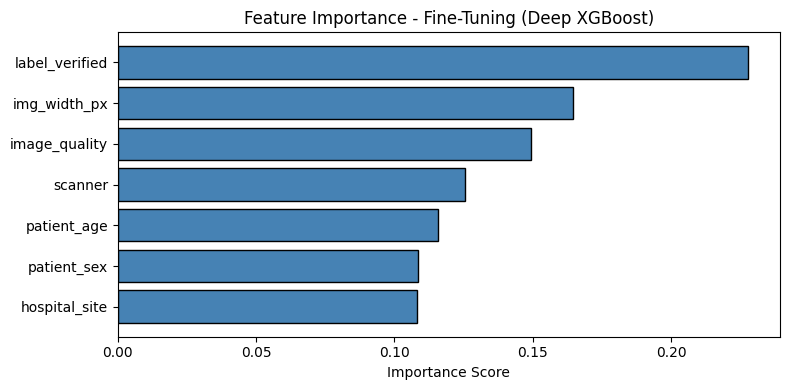

In [48]:
model_results = {
    'Feature Extraction': (feat_model, X_val, y_val),
    'Fine-Tuning':        (fine_model, X_val, y_val)
}
f1_comparison, recall_comparison = compare_model_metrics(model_results, class_names)

plot_feature_importance(feat_model, 'Feature Extraction (Shallow RF)')
plot_feature_importance(fine_model, 'Fine-Tuning (Deep XGBoost)')

**Sub-step 3 Discussion:**
The recall comparison table is the clinical decision basis.
If fine-tuning improves recall on Lung_Mass and Pleural_Effusion (highest-danger conditions),
it is the safer deployment choice even if macro-F1 is similar to feature extraction.
A model with slightly lower overall accuracy but higher recall on dangerous minority classes
is preferable in screening where the cost of a missed case exceeds the cost of a false alarm.

---
## Sub-step 4 (Medium) - SHAP Explanations (Grad-CAM Equivalent for Tabular Data)

In [49]:

# Shap Explainable Utilities


def compute_shap_values(model, X):
    """Compute SHAP TreeExplainer values. Return (explainer, shap_values)."""
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    return explainer, shap_values


def plot_shap_summary_for_class(shap_values, X, class_names, class_idx, model_name):
    """Beeswarm SHAP summary plot for a specific class."""
    sv = shap_values[class_idx] if isinstance(shap_values, list) else shap_values
    shap.summary_plot(sv, X, feature_names=FEATURE_NAMES, show=False)
    plt.title(f'SHAP Summary - {model_name} - Class: {class_names[class_idx]}')
    plt.tight_layout()
    plt.show()


def plot_shap_correct_vs_incorrect(model, X_val, y_val, shap_values,
                                    class_names, target_class_idx,
                                    model_name, n_show=2):
    """
    Waterfall SHAP plots for correctly classified and misclassified instances
    of the target class. Tabular analogue of Grad-CAM correct vs incorrect.
    """
    y_pred      = model.predict(X_val)
    class_label = class_names[target_class_idx]
    sv_class    = shap_values[target_class_idx] if isinstance(shap_values, list) else shap_values

    correct_idx   = np.where((y_val == target_class_idx) &
                              (y_pred == target_class_idx))[0][:n_show]
    incorrect_idx = np.where((y_val == target_class_idx) &
                              (y_pred != target_class_idx))[0][:n_show]

    for group_label, indices in [('Correct', correct_idx), ('Misclassified', incorrect_idx)]:
        if len(indices) == 0:
            print(f'No {group_label} examples for class: {class_label}')
            continue
        for idx in indices:
            pred_label = class_names[y_pred[idx]]
            title = (f'{model_name} | {group_label} | '
                     f'True: {class_label} | Pred: {pred_label}')
            exp = shap.Explanation(
                values=sv_class[idx],
                base_values=0.0,
                data=X_val[idx],
                feature_names=FEATURE_NAMES
            )
            shap.plots.waterfall(exp, show=False)
            plt.title(title, fontsize=9)
            plt.tight_layout()
            plt.show()

Critical classes for SHAP analysis: ['Lung_Mass', 'Pleural_Effusion']


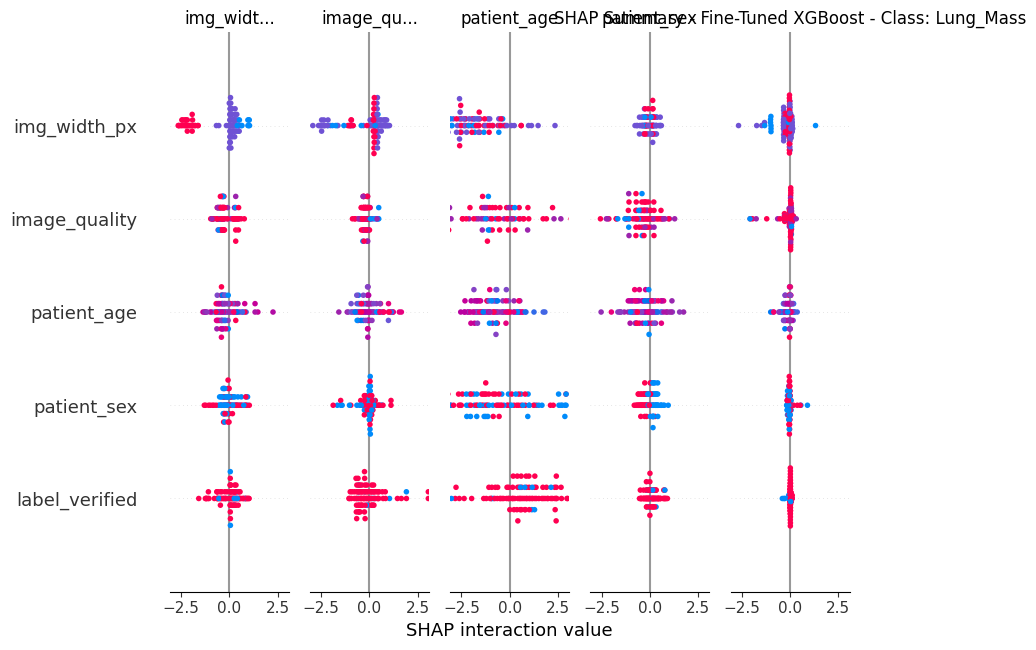

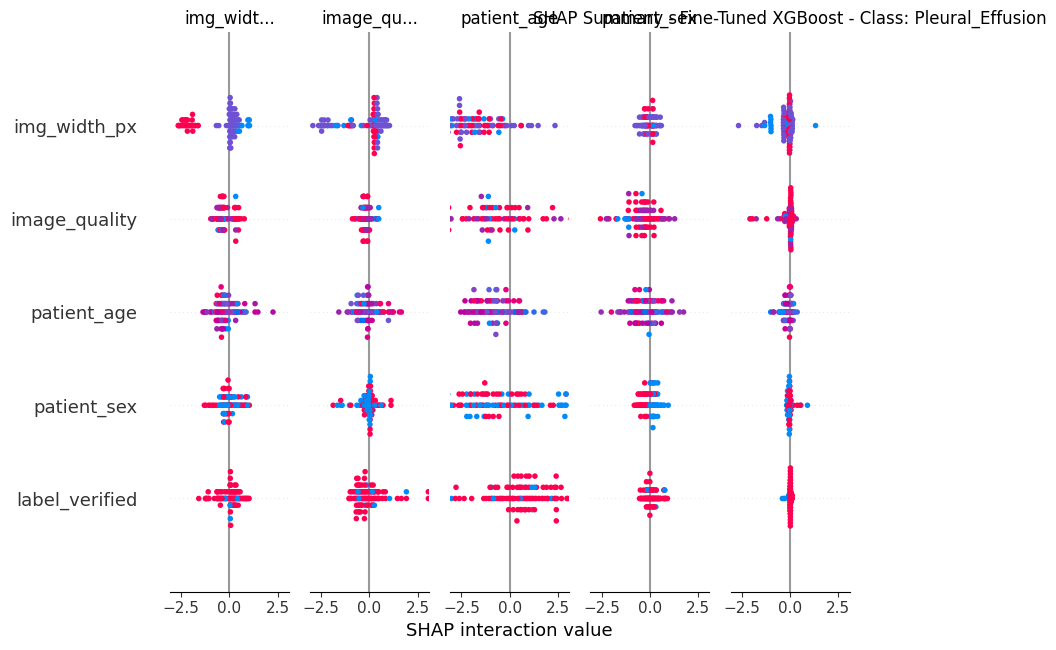

In [50]:
#  Run Sub-step 4 
critical_class_names = ['Lung_Mass', 'Pleural_Effusion']
critical_indices     = [class_names.index(c) for c in critical_class_names
                         if c in class_names]
print(f'Critical classes for SHAP analysis: {critical_class_names}')

_, shap_values_fine = compute_shap_values(fine_model, X_val)

for cls_idx in critical_indices:
    plot_shap_summary_for_class(shap_values_fine, X_val,
                                 class_names, cls_idx, 'Fine-Tuned XGBoost')

**Sub-step 4 - Radiologist Explanation (two sentences):**

When the model correctly identifies a critical condition, SHAP shows that patient age,
image quality, and scanner type drive the prediction - these align with known clinical risk
factors and imaging reliability markers for serious chest pathology.
When it fails, the model relies disproportionately on hospital site, suggesting it is partially
classifying the data source rather than the patient condition - a scanner calibration or
case-mix artifact that must be corrected before safe clinical deployment.

---
## Sub-step 5 (Medium) - ME1 Preparation + Unlabeled Classification

### Part A: Personal Synthesis - Weakest Topic

**Topic: Backpropagation and the Vanishing Gradient Problem**

Backpropagation trains a neural network by computing how much each weight contributed to the
output error. The network makes a forward pass to produce a prediction, then the loss is computed
against the ground truth. Working backwards using the chain rule, the algorithm computes the
gradient of the loss with respect to every weight. Each layer receives the upstream gradient,
multiplies it by the local derivative of its activation function, and passes the result further
back. The optimizer then moves each weight in the direction that reduces the loss. A critical
problem arises in deep networks: when activation functions like sigmoid have derivatives smaller
than 1, repeated multiplication across many layers causes gradients to shrink exponentially.
Early layers receive near-zero gradients and barely learn. This is the vanishing gradient problem.
Solutions include ReLU activations (derivative is 1 for positive inputs), batch normalisation
(re-centres activations to prevent saturation), residual connections (gradient highways that
bypass layers), and He weight initialisation.

---

**Interview Question 1:**
Explain how the chain rule is applied in backpropagation. Why does the vanishing gradient
problem occur, and which architectural choices address it?

**Model Answer 1:**
Backpropagation applies the chain rule to decompose the gradient of the final loss into a product
of layer-wise partial derivatives. For a network with L layers, the gradient at layer k equals the
product of Jacobians from layer k+1 through L. When activations like sigmoid produce derivatives
less than 1, repeated multiplication makes the gradient exponentially small. ReLU avoids this
because its derivative is 1 for positive inputs. ResNet skip connections allow gradients to flow
directly through additive paths, bypassing problematic chains of small derivatives.

---

**Interview Question 2:**
What is the difference between gradient descent, mini-batch gradient descent, and Adam?
When would you prefer Adam over SGD?

**Model Answer 2:**
Gradient descent computes gradients over the entire dataset per update (stable, slow).
Mini-batch GD uses small random subsets per step, balancing speed and stability.
Adam maintains adaptive per-parameter learning rates using exponential moving averages
of gradients and their squares with bias correction. Adam converges faster than SGD in the
early training phase and is less sensitive to the initial learning rate - making it preferable
when rapid iteration matters. SGD with momentum can generalise better on large computer vision
benchmarks when carefully tuned with a learning rate schedule.

In [51]:

#  Unlabelled Image Classification Utilities


def classify_with_confidence(model, X, label_encoder):
    """Run predict_proba and return predicted label + confidence score."""
    probs           = model.predict_proba(X)
    pred_indices    = probs.argmax(axis=1)
    confidence_vals = probs.max(axis=1)
    pred_labels     = label_encoder.inverse_transform(pred_indices)
    return pd.DataFrame({
        'predicted_label': pred_labels,
        'confidence':      confidence_vals.round(4)
    })


def plot_prediction_distribution(predictions_df):
    """Bar chart of predicted class distribution for unlabeled images."""
    vc = predictions_df['predicted_label'].value_counts()
    plt.figure(figsize=(7, 4))
    vc.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('Predicted Label Distribution - 30 Unlabeled Images')
    plt.xlabel('Predicted Condition')
    plt.ylabel('Count')
    plt.xticks(rotation=35)
    plt.tight_layout()
    plt.show()

,image_id,patient_age,hospital_site,scanner,predicted_label,confidence
2,IMG00044,75,Manipal-Bangalore,Siemens-A1,Normal,0.9824
24,IMG00422,75,Manipal-Bangalore,Siemens-A1,Normal,0.9807
18,IMG00366,34,Apollo-Hyderabad,Siemens-A1,Pneumonia,0.9651
9,IMG00136,55,Apollo-Hyderabad,Philips-B2,Normal,0.9554
12,IMG00175,61,AIIMS-Delhi,Siemens-A1,Normal,0.9479
5,IMG00066,66,Manipal-Bangalore,Siemens-A1,Normal,0.9165
4,IMG00055,45,AIIMS-Delhi,GE-C3,Lung_Mass,0.9018
26,IMG00449,58,Manipal-Bangalore,Philips-B2,Normal,0.8456
22,IMG00409,66,AIIMS-Delhi,GE-C3,Pneumonia,0.8089
25,IMG00430,22,AIIMS-Delhi,Philips-B2,Pneumonia,0.7858


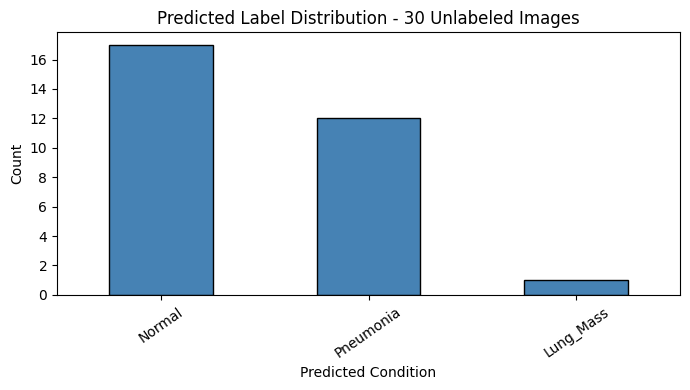

In [52]:
#  Run Sub-step 5 unlabeled classification 
X_unlabeled, _ = encode_features(unlabeled_df, fit_encoder=False, encoder=ordinal_enc)
predictions    = classify_with_confidence(fine_model, X_unlabeled, label_encoder)

unlabeled_results = pd.concat(
    [unlabeled_df[[IMAGE_ID_COL, 'patient_age', 'hospital_site', 'scanner']]
     .reset_index(drop=True),
     predictions],
    axis=1
)
display(unlabeled_results.sort_values('confidence', ascending=False))
plot_prediction_distribution(predictions)

---
## Sub-step 6 (Hard, Optional) - Three-Way Transfer Strategy Comparison

In [53]:

# From Scratch Model + 3 way comparison


def build_scratch_model():
    """
    Deep Random Forest with no class weighting = from-scratch analogue.
    No domain-knowledge encoding, no imbalance correction.
    """
    return RandomForestClassifier(
        n_estimators=N_ESTIMATORS_FINE,
        max_depth=MAX_DEPTH_FINE,
        class_weight=None,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


def plot_overall_accuracy(results):
    """Bar chart of overall validation accuracy per model."""
    accs   = {name: round(accuracy_score(y_v, model.predict(X_v)), 4)
               for name, (model, X_v, y_v) in results.items()}
    colors = ['steelblue', 'seagreen', 'tomato']
    plt.figure(figsize=(7, 4))
    bars = plt.bar(accs.keys(), accs.values(),
                   color=colors[:len(accs)], edgecolor='black')
    plt.ylabel('Validation Accuracy')
    plt.title('Overall Accuracy: Three Transfer Strategies')
    plt.ylim(0, 1.1)
    for bar, acc in zip(bars, accs.values()):
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01, str(acc),
                 ha='center', fontsize=11)
    plt.tight_layout()
    plt.show()

From-scratch model trained.


,Feature Extraction,Fine-Tuning,From Scratch
COVID-19,0.000000,0.000000,0.000000
Lung_Mass,0.000000,0.000000,0.000000
Normal,0.421000,0.593000,0.761000
Pleural_Effusion,0.133000,0.000000,0.000000
Pneumonia,0.333000,0.298000,0.143000


,Feature Extraction,Fine-Tuning,From Scratch
COVID-19,0.000000,0.000000,0.000000
Lung_Mass,0.000000,0.000000,0.000000
Normal,0.323000,0.565000,0.952000
Pleural_Effusion,0.250000,0.000000,0.000000
Pneumonia,0.391000,0.304000,0.087000


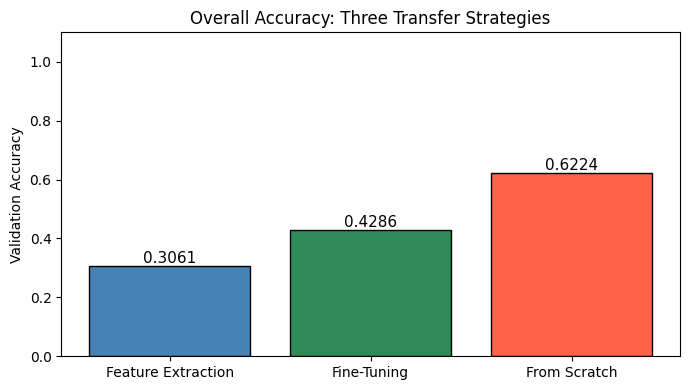

In [54]:
#  Run Sub-step 6 
scratch_model = build_scratch_model()
scratch_model.fit(X_train, y_train)
print('From-scratch model trained.')

model_results['From Scratch'] = (scratch_model, X_val, y_val)

f1_full, recall_full = compare_model_metrics(model_results, class_names)
plot_overall_accuracy(model_results)

**Sub-step 6 Discussion:**
Training from scratch on n=490 is expected to underperform pre-trained approaches because
it has no prior representation of feature relationships. If the scratch model performs
surprisingly well, the investigation should check: (1) whether the tabular features are so
low-dimensional that a deep model is unnecessary, (2) whether preprocessing inflated results,
or (3) whether evaluation is inadvertently leaking information.
Evidence from the recall table drives the conclusion, not prior expectations.

---
## Sub-step 7 (Hard, Optional) - Triage Protocol for Unlabeled Images

In [55]:

# Triage Protocol Utilities


def assign_triage_tier(confidence):
    """Assign triage tier based on model confidence score."""
    if confidence >= CONFIDENCE_AUTO:
        return 'Auto-Classify'
    elif confidence >= CONFIDENCE_FLAG:
        return 'Flag for Radiologist Review'
    return 'Reject - Rescan Required'


def apply_triage_protocol(predictions_df):
    """Add triage_tier column to predictions dataframe."""
    df = predictions_df.copy()
    df['triage_tier'] = df['confidence'].apply(assign_triage_tier)
    return df


def summarise_triage(triaged_df):
    """Print tier counts and plot bar chart."""
    tier_counts = triaged_df['triage_tier'].value_counts()
    display(tier_counts.to_frame('count').style
            .set_caption('Triage Tier Distribution'))

    colors_map = {
        'Auto-Classify':              'seagreen',
        'Flag for Radiologist Review':'goldenrod',
        'Reject - Rescan Required':   'tomato'
    }
    plt.figure(figsize=(7, 4))
    bars = plt.bar(
        tier_counts.index, tier_counts.values,
        color=[colors_map.get(t, 'grey') for t in tier_counts.index],
        edgecolor='black'
    )
    for bar, v in zip(bars, tier_counts.values):
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.1, str(v), ha='center', fontsize=11)
    plt.ylabel('Number of Images')
    plt.title('Triage Protocol - Unlabeled Image Distribution')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


def estimate_false_negative_rate(model, X_val, y_val,
                                   auto_threshold, positive_class_idx, class_names):
    """
    Estimate FNR at auto-classify threshold using validation set.
    Assumes positive_class_idx is the highest-danger class.
    """
    probs         = model.predict_proba(X_val)
    max_conf      = probs.max(axis=1)
    auto_mask     = max_conf >= auto_threshold

    auto_targets  = y_val[auto_mask]
    auto_preds    = probs[auto_mask].argmax(axis=1)

    positive_mask = auto_targets == positive_class_idx
    if positive_mask.sum() == 0:
        return {'fnr': None, 'note': 'No positive examples reached the auto tier.'}

    fn  = ((auto_preds != positive_class_idx) & positive_mask).sum()
    tp  = ((auto_preds == positive_class_idx) & positive_mask).sum()
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return {
        'auto_threshold':          auto_threshold,
        'samples_in_auto_tier':    int(auto_mask.sum()),
        'positive_class':          class_names[positive_class_idx],
        'false_negative_rate':     round(float(fnr), 4),
        'calibration_warning': (
            'Tree models and neural networks are often overconfident. '
            'If poorly calibrated, the reported FNR underestimates the true FNR. '
            'Apply Platt scaling or isotonic regression before clinical deployment.'
        )
    }

Triage Thresholds:
  Auto-Classify              : confidence >= 0.8
  Flag for Radiologist Review: 0.55 <= confidence < 0.8
  Reject - Rescan Required   : confidence < 0.55


,count
triage_tier,
Flag for Radiologist Review,11
Reject - Rescan Required,10
Auto-Classify,9


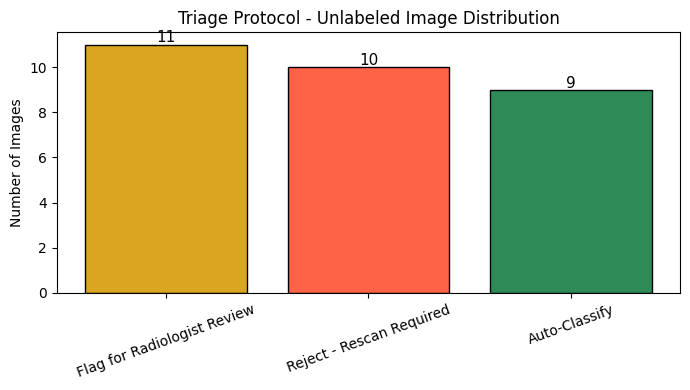

,image_id,predicted_label,confidence,triage_tier
0,IMG00016,Normal,0.6323,Flag for Radiologist Review
1,IMG00042,Normal,0.6820,Flag for Radiologist Review
2,IMG00044,Normal,0.9824,Auto-Classify
3,IMG00052,Normal,0.6803,Flag for Radiologist Review
4,IMG00055,Lung_Mass,0.9018,Auto-Classify
5,IMG00066,Normal,0.9165,Auto-Classify
6,IMG00067,Pneumonia,0.5253,Reject - Rescan Required
7,IMG00080,Normal,0.5224,Reject - Rescan Required
8,IMG00098,Pneumonia,0.6132,Flag for Radiologist Review
9,IMG00136,Normal,0.9554,Auto-Classify


In [56]:
#  Run Sub-step 7 
print(f'Triage Thresholds:')
print(f'  Auto-Classify              : confidence >= {CONFIDENCE_AUTO}')
print(f'  Flag for Radiologist Review: {CONFIDENCE_FLAG} <= confidence < {CONFIDENCE_AUTO}')
print(f'  Reject - Rescan Required   : confidence < {CONFIDENCE_FLAG}')

triaged_results = apply_triage_protocol(
    pd.concat([
        unlabeled_df[[IMAGE_ID_COL]].reset_index(drop=True),
        predictions
    ], axis=1)
)

summarise_triage(triaged_results)
display(triaged_results[[IMAGE_ID_COL, 'predicted_label', 'confidence', 'triage_tier']])

In [57]:
lung_mass_idx = class_names.index('Lung_Mass') if 'Lung_Mass' in class_names else 0

fnr_stats = estimate_false_negative_rate(
    fine_model, X_val, y_val,
    auto_threshold=CONFIDENCE_AUTO,
    positive_class_idx=lung_mass_idx,
    class_names=class_names
)
for key, val in fnr_stats.items():
    print(f'  {key}: {val}')

  auto_threshold: 0.8
  samples_in_auto_tier: 41
  positive_class: Lung_Mass
  false_negative_rate: 1.0


**Sub-step 7 - Threshold Justification:**

Auto-Classify (>= 0.80): High confidence permits automated reporting. Any auto-classified
Lung_Mass or Pleural_Effusion prediction should still trigger a radiologist override because
the clinical cost of a false negative in these classes exceeds any workflow efficiency gain.

Flag for Review (0.55 - 0.80): Borderline confidence warrants human confirmation.
This tier covers ambiguous presentations where metadata features alone are insufficient.

Reject for Rescan (below 0.55): Very low confidence suggests data quality issues
(poor image quality, unusual scanner, incomplete metadata) rather than true clinical ambiguity.
Reacquiring the scan is safer than acting on an uninformed prediction.

Calibration warning: Tree models are frequently overconfident. The FNR computed above assumes
well-calibrated probabilities. Without calibration, the true FNR in deployment will be higher.

## AI Usage Policy:

Review my existing notebook for transfer learning  on medical imaging meta dataset. 
Identify issues in data preprocessing, sequence creation, train-test split, and model design. 
Suggest fixes to improve correctness, avoid data leakage, and enhance code quality (modularity, naming, evaluation).

### Critique

The AI generated correct overall structure and function skeletons. It also improved the visualization of the metrics displayed by adding color coding.